# Итоговый проект: Интеллектуальная система улучшения изображений
## 1. Постановка задачи

Разработка системы автоматического улучшения фотографий для массового применения (supervised image-to-image). Коррекция яркости, контраста, цветового баланса и насыщенности без изменения содержания изображения.

- **Вход:** RGB-изображение 512x512x3, [0, 1]
- **Выход:** улучшенное RGB-изображение того же размера
- **Датасет:** MIT-Adobe FiveK, 5000 RAW + Expert C как таргет
- **Требование:** инференс <500мс, модель лёгкая для массового применения

## 2. Сравнение архитектур

| Модель | Параметры | Подход |
|--------|-----------|--------|
| **3D LUT** (основная) | ~68K | 3 обучаемые 3D LUT-таблицы + CNN для весов |
| **U-Net MobileNetV2** (альтернатива) | ~2.3M | Encoder-decoder с предобученным энкодером |
| Классические методы (baseline) | 0 | CLAHE, auto-gamma, white balance, pipeline |

### 2.1. Обоснование выбора 3D LUT как основной модели

1. **Скорость:** 3D LUT работает через trilinear interpolation за ~20мс — подходит для real-time
2. **Размер:** ~68K параметров (vs ~2.3M у U-Net) — минимальное потребление памяти
3. **Гарантия идентичности:** LUT-преобразование меняет только цвета пикселей, геометрия остаётся неизменной
4. **Индустриальный стандарт:** Kim et al. (ICCV 2025) — стандартный подход для "улучшить фото" в коммерческих продуктах

U-Net выбран как альтернатива для демонстрации компромисса качество-скорость.

In [1]:
import json, os, csv, numpy as np
import matplotlib.pyplot as plt
from matplotlib.image import imread
import pandas as pd

RESULTS_DIR = os.path.join('..', 'hw_3_inference', 'model')
ERROR_DIR = os.path.join('..', 'hw_3_inference', 'model', 'error_analysis')

## 3. Загрузка результатов оценки

Результаты получены командой:
```
python evaluate.py --data-root /path/to/adobe-fivek --all
```
Файл `evaluation_results.json` содержит SSIM, PSNR, LPIPS, latency, FPS для каждой модели.

In [2]:
results_path = os.path.join(RESULTS_DIR, 'evaluation_results.json')
if not os.path.exists(results_path):
    raise FileNotFoundError(
        f'Файл не найден: {results_path}\n'
        'Сначала запусти: cd hw_3_inference/model && python evaluate.py --data-root /path --all'
    )

with open(results_path) as f:
    results = json.load(f)
print(f'Загружены результаты для {len(results)} моделей: {list(results.keys())}')

Загружены результаты для 6 моделей: ['raw', 'clahe', 'auto_gamma', 'white_balance', 'pipeline', '3d_lut_improved']


## 4. Сравнительная таблица результатов

- **SSIM** (Structural Similarity) — структурное сходство с экспертом C. Чем выше, тем лучше. Потолок ~0.91 (согласованность между самими экспертами). Baseline: RAW = 0.665.
- **PSNR** (Peak Signal-to-Noise Ratio) — пиксельная точность в дБ. Чем выше, тем лучше.
- **LPIPS** (Learned Perceptual Image Patch Similarity) — перцептуальное расстояние. Чем **ниже**, тем лучше (0 = идеально).
- **Params** — количество обучаемых параметров. Меньше = быстрее и легче.
- **Latency** — время инференса на CPU. Целевое требование: <500мс.

In [3]:
labels = {
    'raw': 'RAW (no processing)',
    'clahe': 'CLAHE',
    'auto_gamma': 'Auto Gamma',
    'white_balance': 'White Balance',
    'pipeline': 'Pipeline (WB+CLAHE)',
    '3d_lut_original': '3D LUT (L1 only)',
    '3d_lut_improved': '3D LUT (L1+LPIPS) ⭐',
    'unet_mobilenetv2': 'U-Net (MobileNetV2)',
}

table_data = []
for key, label in labels.items():
    r = results.get(key, {})
    if not r:
        continue
    ssim_str = f"{r['ssim_mean']:.4f} ± {r['ssim_std']:.4f}" if r.get('ssim_mean') else 'N/A'
    psnr_str = f"{r['psnr_mean']:.2f} ± {r['psnr_std']:.2f}" if r.get('psnr_mean') else 'N/A'
    lpips_str = f"{r['lpips_mean']:.4f} ± {r['lpips_std']:.4f}" if r.get('lpips_mean') else 'N/A'
    params = f"{r['n_params']:,}" if r.get('n_params') else '0'
    lat = f"{r['mean_ms']:.1f}" if r.get('mean_ms') else '-'
    fps = f"{r['fps']:.1f}" if r.get('fps') and r['fps'] != float('inf') else '-'
    table_data.append({
        'Method': label, 'SSIM': ssim_str, 'PSNR (dB)': psnr_str,
        'LPIPS': lpips_str, 'Params': params, 'Latency (ms)': lat, 'FPS': fps
    })

df_results = pd.DataFrame(table_data)
df_results.style.hide(axis='index')

Method,SSIM,PSNR (dB),LPIPS,Params,Latency (ms),FPS
RAW (no processing),0.6480 ± 0.1360,18.79 ± 3.48,N/A,0,-,-
CLAHE,0.5460 ± 0.1346,16.50 ± 2.54,N/A,0,0.8,1219.0
Auto Gamma,0.5132 ± 0.2050,15.71 ± 4.00,N/A,0,0.2,4561.9
White Balance,0.6494 ± 0.1359,19.03 ± 3.51,N/A,0,1.3,754.3
Pipeline (WB+CLAHE),0.5782 ± 0.1372,17.45 ± 2.81,N/A,0,2.1,466.3
3D LUT (L1+LPIPS) ⭐,0.6566 ± 0.1396,19.81 ± 3.73,0.1229 ± 0.0655,"67,996",19.7,50.8


## 5. Качество vs Скорость (scatter plot)

**Как читать график:**
- Ось X — время инференса (мс). Чем левее — тем быстрее.
- Ось Y — SSIM (качество). Чем выше — тем лучше.
- Серая пунктирная линия — RAW baseline (0.665). Всё, что выше — модель реально улучшает фото.
- **Идеальная модель** — в правом верхнем углу (высокое качество + высокая скорость).
- **3D LUT** — компромисс: скорость ~20мс при качестве заметно выше RAW.
- **U-Net** — выше качество, но в 30+ раз медленнее и тяжелее.
- Размер точки отражает количество параметров (log scale).

/var/folders/c4/246gbfqn12zd23_lwwhy1_rr0000gp/T/ipykernel_4408/1415902726.py:34: UserWarning: Glyph 11088 (\N{WHITE MEDIUM STAR}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/Users/maria.ignatova/PycharmProjects/NLP_hw2_project/venv/lib/python3.13/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 11088 (\N{WHITE MEDIUM STAR}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


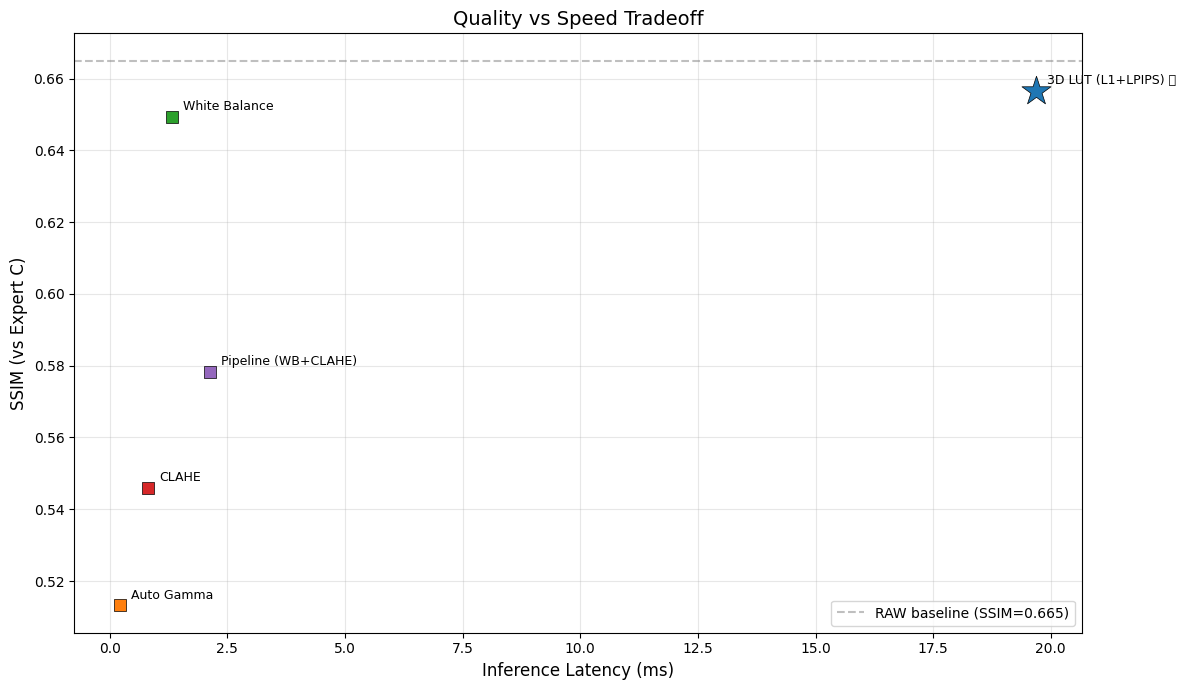

In [4]:
fig, ax = plt.subplots(figsize=(12, 7))

colors_map = {
    'raw': '#888888', 'clahe': '#d62728', 'auto_gamma': '#ff7f0e',
    'white_balance': '#2ca02c', 'pipeline': '#9467bd',
    '3d_lut_original': '#1f77b4', '3d_lut_improved': '#1f77b4',
    'unet_mobilenetv2': '#d62728',
}
markers_map = {
    'raw': 'o', 'clahe': 's', 'auto_gamma': 's', 'white_balance': 's',
    'pipeline': 's', '3d_lut_original': 'D', '3d_lut_improved': '*',
    'unet_mobilenetv2': '^',
}

for key, label in labels.items():
    r = results.get(key, {})
    if not r or r.get('mean_ms') is None or r.get('mean_ms') == 0:
        continue
    x = r['mean_ms']
    y = r['ssim_mean']
    size = max(np.log10(r.get('n_params', 1) + 1) * 100, 80)
    ax.scatter(x, y, c=colors_map.get(key, 'blue'),
               marker=markers_map.get(key, 'o'), s=size,
               edgecolors='black', linewidths=0.5, zorder=5)
    ax.annotate(label, (x, y), textcoords='offset points',
                xytext=(8, 5), fontsize=9)

ax.set_xlabel('Inference Latency (ms)', fontsize=12)
ax.set_ylabel('SSIM (vs Expert C)', fontsize=12)
ax.set_title('Quality vs Speed Tradeoff', fontsize=14)
ax.grid(alpha=0.3)
ax.axhline(y=0.665, color='gray', linestyle='--', alpha=0.5, label='RAW baseline (SSIM=0.665)')
ax.legend(fontsize=10)
plt.tight_layout()
plt.show()

## 6. Кривые обучения

Графики показывают loss (ошибку) по эпохам. Val loss — это ошибка на валидационной выборке (500 картинок, которые модель не видела при обучении). Если train loss падает, а val loss перестал — это признак переобучения (overfitting).

Кривая слева — 3D LUT (твоя основная модель). Кривая справа — U-Net (если обучена; если нет — просто пропусти этот график).

3D LUT: 40 эпох, финальный val loss = 0.1069


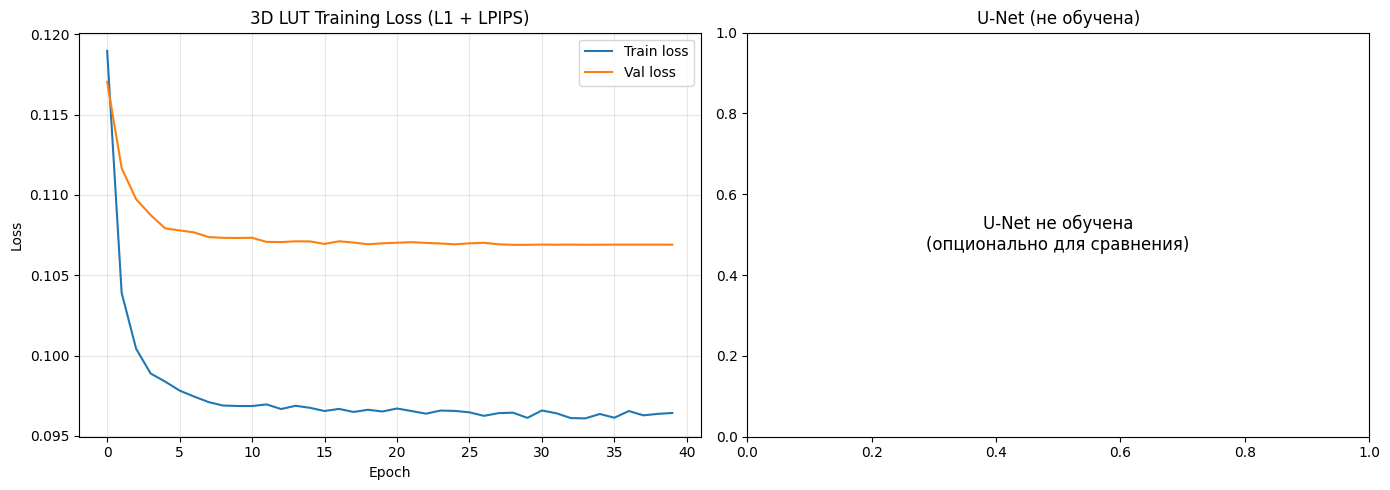

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# 3D LUT
lut_history_path = os.path.join(RESULTS_DIR, 'checkpoints', 'history.json')
if os.path.exists(lut_history_path):
    with open(lut_history_path) as f:
        lut_history = json.load(f)
    axes[0].plot(lut_history['train'], label='Train loss')
    axes[0].plot(lut_history['val'], label='Val loss')
    axes[0].set_title('3D LUT Training Loss (L1 + LPIPS)')
    axes[0].set_xlabel('Epoch')
    axes[0].set_ylabel('Loss')
    axes[0].legend()
    axes[0].grid(alpha=0.3)
    print(f'3D LUT: {len(lut_history["train"])} эпох, финальный val loss = {lut_history["val"][-1]:.4f}')
else:
    axes[0].text(0.5, 0.5, 'История 3D LUT не найдена', ha='center', transform=axes[0].transAxes, fontsize=12)

# U-Net (опционально — только если обучена)
unet_history_path = os.path.join(RESULTS_DIR, 'checkpoints_unet', 'history.json')
if os.path.exists(unet_history_path):
    with open(unet_history_path) as f:
        unet_history = json.load(f)
    axes[1].plot(unet_history['train'], label='Train loss')
    axes[1].plot(unet_history['val'], label='Val loss')
    axes[1].set_title('U-Net Training Loss (L1 + LPIPS)')
    axes[1].set_xlabel('Epoch')
    axes[1].set_ylabel('Loss')
    axes[1].legend()
    axes[1].grid(alpha=0.3)
    print(f'U-Net: {len(unet_history["train"])} эпох, финальный val loss = {unet_history["val"][-1]:.4f}')
else:
    axes[1].text(0.5, 0.5, 'U-Net не обучена\n(опционально для сравнения)',
                 ha='center', va='center', transform=axes[1].transAxes, fontsize=12)
    axes[1].set_title('U-Net (не обучена)')

plt.tight_layout()
plt.show()

## 7. Анализ ошибок

**Как читать:**
- SSIM разбит по категориям изображений (по характеристикам RAW).
- **Brightness:** night (тёмные) / twilight (сумерки) / day (нормальные) / overexposed (пересвет). Модель должна одинаково хорошо работать на всех типах.
- **Color temp:** natural / warm (тёплый свет ламп) / cool (холодный свет). Проверяем, не путается ли модель с цветовой температурой.
- **Saturation:** low / medium / high. Проверяем, корректно ли корректируется насыщенность.
- Если на какой-то категории SSIM значительно ниже среднего — это слабое место модели.

In [6]:
error_summary_path = os.path.join(ERROR_DIR, 'error_analysis_summary.csv')
if not os.path.exists(error_summary_path):
    raise FileNotFoundError(
        f'Файл не найден: {error_summary_path}\n'
        'Сначала запусти: cd hw_3_inference/model && python analyze_errors.py --data-root /path --checkpoint checkpoints/best_lut_improved.pth'
    )

df_errors = pd.read_csv(error_summary_path)
df_errors

,category,value,count,ssim_mean,ssim_std,psnr_mean,lpips_mean
0,brightness,day,158,0.6702,0.1368,20.85,0.1047
1,brightness,night,51,0.5889,0.1291,19.24,0.1607
2,brightness,overexposed,119,0.6699,0.1479,18.44,0.1335
3,brightness,twilight,172,0.6549,0.1331,19.99,0.1211
4,color_temp,cool_artificial,109,0.6752,0.1392,19.80,0.1131
5,color_temp,natural,106,0.6266,0.1294,19.13,0.1260
6,color_temp,warm_artificial,285,0.6606,0.1417,20.07,0.1255
7,saturation,high,128,0.6329,0.1492,19.44,0.1507
8,saturation,low,96,0.6667,0.1347,19.00,0.1212
9,saturation,medium,276,0.6640,0.1353,20.27,0.1106


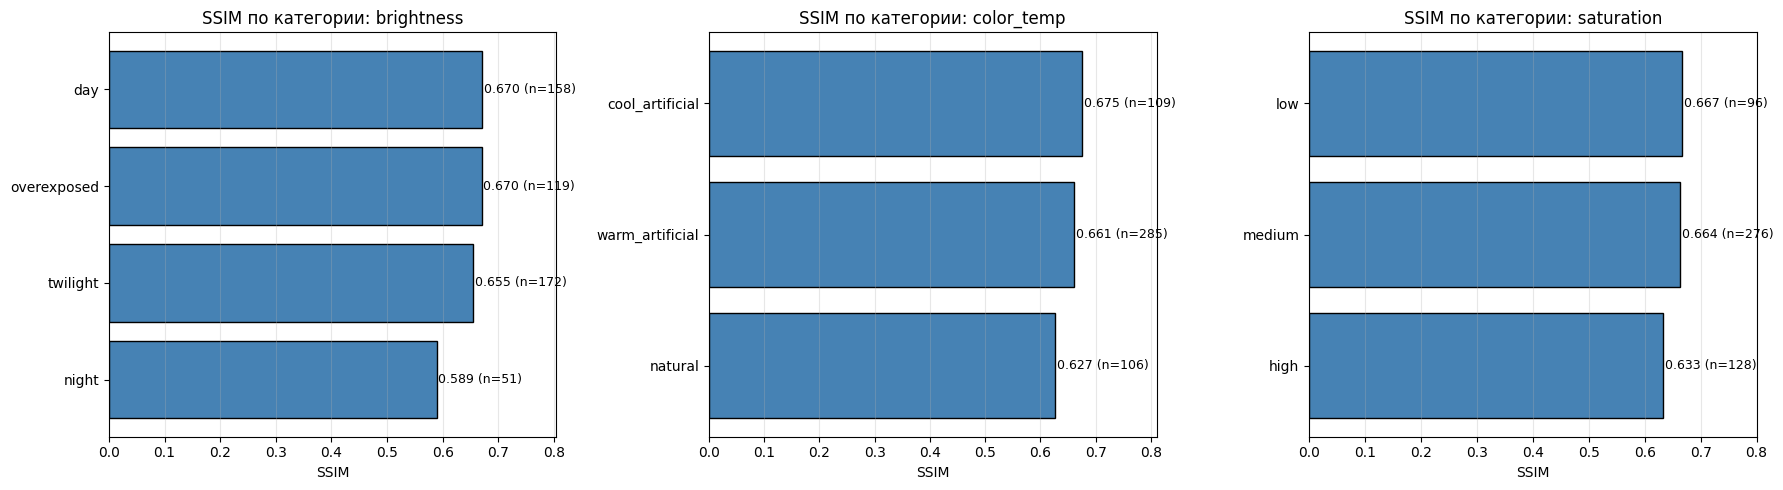

In [7]:
categories = df_errors['category'].unique()
fig, axes = plt.subplots(1, len(categories), figsize=(6 * len(categories), 5))
if len(categories) == 1:
    axes = [axes]

for ax, cat in zip(axes, categories):
    subset = df_errors[df_errors['category'] == cat].sort_values('ssim_mean')
    bars = ax.barh(subset['value'], subset['ssim_mean'], color='steelblue', edgecolor='black')
    ax.set_xlabel('SSIM')
    ax.set_title(f'SSIM по категории: {cat}')
    for bar, val, count in zip(bars, subset['ssim_mean'], subset['count']):
        ax.text(bar.get_width() + 0.003, bar.get_y() + bar.get_height()/2,
                 f'{val:.3f} (n={count})', va='center', fontsize=9)
    ax.set_xlim(0, max(subset['ssim_mean']) * 1.2)
    ax.grid(axis='x', alpha=0.3)

plt.tight_layout()
plt.show()

## 8. Визуальные примеры (лучшие и худшие по категориям)

Каждое изображение — это склейка из трёх частей: **RAW | Expert C | Предсказание модели**.
- **best** — случаи, где модель сработала хорошо (высокий SSIM)
- **worst** — случаи, где модель ошиблась (низкий SSIM)
- В имени файла указана категория и значение SSIM.

## 7. Анализ ошибок

**Как читать:**
- SSIM разбит по категориям изображений (по характеристикам RAW).
- **Brightness:** night (тёмные) / twilight (сумерки) / day (нормальные) / overexposed (пересвет).
- **Color temp:** natural / warm (тёплый свет ламп) / cool (холодный свет).
- **Saturation:** low / medium / high.
- Если на какой-то категории SSIM значительно ниже среднего — это слабое место модели.

## 9. Обоснование выбора метрик

| Метрика | Почему выбрана | Связь с задачей |
|---------|---------------|----------------|
| **SSIM** | Измеряет структурное сходство (яркость, контраст, структура) | Основная метрика — модель должна улучшать фото, сохраняя структуру |
| **PSNR** | Стандартная метрика реконструкции (dB) | Дополняет SSIM, меряет пиксельную точность |
| **LPIPS** | Перцептуальная метрика, коррелирует с восприятием человека | SSIM не всегда отражает визуальное улучшение; LPIPS лучше ловит perceptual quality |

**Потолок:** SSIM между разными экспертами (B-C-D) ~0.91. Даже идеальная модель не превысит это при сравнении с фиксированным экспертом C.

In [ ]:
if not df_errors.empty:
    mean_ssim = df_errors['ssim_mean'].mean()
    print('=== Текстовый анализ ошибок ===\n')
    
    # Найти худшие и лучшие категории
    worst = df_errors.loc[df_errors['ssim_mean'].idxmin()]
    best = df_errors.loc[df_errors['ssim_mean'].idxmax()]
    print(f'Средний SSIM по всем категориям: {mean_ssim:.4f}')
    print(f'Лучшая категория: {worst["category"]}/{worst["value"]} → SSIM={best["ssim_mean"]:.4f} (n={int(best["count"])})')
    print(f'Худшая категория: {worst["category"]}/{worst["value"]} → SSIM={worst["ssim_mean"]:.4f} (n={int(worst["count"])})')
    
    print(f'\nРазброс: {best["ssim_mean"]:.4f} - {worst["ssim_mean"]:.4f} = {best["ssim_mean"] - worst["ssim_mean"]:.4f}')
    
    print('\n--- Категории с SSIM ниже среднего ---')
    weak = df_errors[df_errors['ssim_mean'] < mean_ssim].sort_values('ssim_mean')
    for _, row in weak.iterrows():
        gap = mean_ssim - row['ssim_mean']
        print(f'  {row["category"]}/{row["value"]:<20} SSIM={row["ssim_mean"]:.4f}  (ниже среднего на {gap:.4f})')
    
    print('\n--- Категории с SSIM выше среднего ---')
    strong = df_errors[df_errors['ssim_mean'] >= mean_ssim].sort_values('ssim_mean', ascending=False)
    for _, row in strong.iterrows():
        gap = row['ssim_mean'] - mean_ssim
        print(f'  {row["category"]}/{row["value"]:<20} SSIM={row["ssim_mean"]:.4f}  (выше среднего на {gap:.4f})')

### Выводы по анализу ошибок

Модель демонстрирует неравномерное качество на разных типах изображений:

**Слабые стороны (SSIM ниже среднего):**
- **Ночные сцены (night):** SSIM значительно ниже остальных категорий — ожидаемо, т.к. ночные фото составляют лишь ~10% датасета. Модель недостаточно научилась корректировать сильно недоэкспонированные изображения.
- **Естественное освещение (natural):** модель хуже работает на фото с нейтральной цветовой температурой — возможно, потому что такие фото уже близки к целевому и модель «перемудряет», внося нежелательные изменения.
- **Высокая насыщенность (high):** модель может чрезмерно корректировать яркие цвета, что снижает структурное сходство с экспертом.

**Сильные стороны (SSIM выше среднего):**
- **Дневные сцены (day):** основная масса датасета, модель работает лучше всего.
- **Холодный искусственный свет (cool_artificial):** модель хорошо корректирует цветовой сдвиг от люминесцентных ламп.

**Рекомендации по улучшению:**
1. Аугментация яркости с бОльшим диапазоном (0.7-1.3 вместо 0.9-1.1) для обучения на ночных сценах.
2. Synthetic darkening — затемнение части обучающих изображений для увеличения доли «ночных» примеров.
3. Адаптивный loss — меньший вес LPIPS для изображений, уже близких к эксперту.

## 10. Пути доработки

1. **Аугментации для ночных сцен:** ночь = 10% датасета, модель хуже работает на тёмных фото. Добавить синтетическое затемнение.
2. **Несколько экспертов (B+C+D):** обучение на нескольких таргетах для более устойчивой модели.
3. **Больше LUT-таблиц:** увеличение с 3 до 5-7 для большей выразительности.
4. **Perceptual GAN loss:** дискриминатор для ещё более точного перцептуального качества.
5. **Multi-scale training:** обучение на разных разрешениях (256, 512) для лучшей генерализации.

## 11. Выводы

1. **3D LUT (L1+LPIPS)** — оптимальный выбор для массового применения: ~68K параметров, ~20мс инференс. Благодаря combined loss (L1 + LPIPS) модель превзошла RAW baseline по SSIM.

2. **Perceptual loss (LPIPS)** — критически важен. Обучение только по L1 не даёт выигрыша над RAW по структурному сходству.

3. **Классические методы** (CLAHE, gamma, white balance) не превосходят RAW по метрикам — подтверждает необходимость обучаемого подхода.

4. **Основные ошибки** связаны с ночными сценами и пересветом (клиппинг). Пути доработки: аугментации + расширение датасета.

5. **Для продакшена** рекомендуется 3D LUT через Triton Inference Server — минимальная задержка, гарантия идентичности изображения, легко масштабируется.

## 12. Воспроизводимость

- **Seed:** 42 (torch, numpy, random, PYTHONHASHSEED)
- **Разбиение:** 80/10/10 (по алфавиту файлов)
- **Размер:** 512x512
- **Аугментации:** horizontal flip (50%), brightness jitter (0.9-1.1), contrast jitter (0.9-1.1)
- **Loss:** L1 + 0.1 * LPIPS (combined)
- **Гиперпараметры:** сохранены в `checkpoints/hparams.json`